<a href="https://colab.research.google.com/github/Castillo-jacqueline/Investigaci-n-de-operaciones/blob/main/Networkx1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial de NetworkX para problemas de redes

En este cuaderno se muestran tres aplicaciones de la biblioteca NetworkX de Python:

1. Árbol de expansión mínima.
2. Ruta más corta.
3. Flujo máximo.

Para cada problema se construirá la red, se aplicará el algoritmo correspondiente y se mostrará gráficamente la solución obtenida.

In [50]:
# ============================================================
# TUTORIAL DE NETWORKX
# Árbol de expansión mínima, ruta más corta y flujo máximo
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt

print("NetworkX cargado correctamente.")

NetworkX cargado correctamente.


## Bibliotecas utilizadas

- `NetworkX`: creación y análisis de grafos.
- `Matplotlib`: visualización de las redes.
# 1. Árbol de expansión mínima

Se busca conectar todos los nodos con el menor peso total y sin formar ciclos.

Para este problema se usa la versión **no dirigida**.

In [51]:
# ============================================================
# 1. ÁRBOL DE EXPANSIÓN MÍNIMA
# ============================================================

# Creamos un grafo no dirigido
G1 = nx.Graph()

# Lista de aristas en formato:
# (nodo_origen, nodo_destino, peso)

aristas_1 = [
    (1, 2, 5),
        (1, 3, 1),
            (2, 3, 2),
                (2, 4, 7),
                    (2, 5, 1),
                        (2, 6, 6),
                            (3, 4, 6),
                                (3, 5, 7),
                                    (4, 5, 3),
                                        (4, 6, 4),
                                            (4, 7, 6),
                                                (5, 6, 5),
                                                    (5, 7, 9),
                                                        (6, 7, 2)
                                                        ]

                                                        # Agregamos las aristas al grafo
for u, v, peso in aristas_1:
                                                            G1.add_edge(u, v, weight=peso)

                                                            # Mostramos información básica de la red
                                                            print("Nodos:", list(G1.nodes()))
                                                            print("Número de nodos:", G1.number_of_nodes())
                                                            print("Número de aristas:", G1.number_of_edges())

Nodos: [1, 2]
Número de nodos: 2
Número de aristas: 1
Nodos: [1, 2, 3]
Número de nodos: 3
Número de aristas: 2
Nodos: [1, 2, 3]
Número de nodos: 3
Número de aristas: 3
Nodos: [1, 2, 3, 4]
Número de nodos: 4
Número de aristas: 4
Nodos: [1, 2, 3, 4, 5]
Número de nodos: 5
Número de aristas: 5
Nodos: [1, 2, 3, 4, 5, 6]
Número de nodos: 6
Número de aristas: 6
Nodos: [1, 2, 3, 4, 5, 6]
Número de nodos: 6
Número de aristas: 7
Nodos: [1, 2, 3, 4, 5, 6]
Número de nodos: 6
Número de aristas: 8
Nodos: [1, 2, 3, 4, 5, 6]
Número de nodos: 6
Número de aristas: 9
Nodos: [1, 2, 3, 4, 5, 6]
Número de nodos: 6
Número de aristas: 10
Nodos: [1, 2, 3, 4, 5, 6, 7]
Número de nodos: 7
Número de aristas: 11
Nodos: [1, 2, 3, 4, 5, 6, 7]
Número de nodos: 7
Número de aristas: 12
Nodos: [1, 2, 3, 4, 5, 6, 7]
Número de nodos: 7
Número de aristas: 13
Nodos: [1, 2, 3, 4, 5, 6, 7]
Número de nodos: 7
Número de aristas: 14


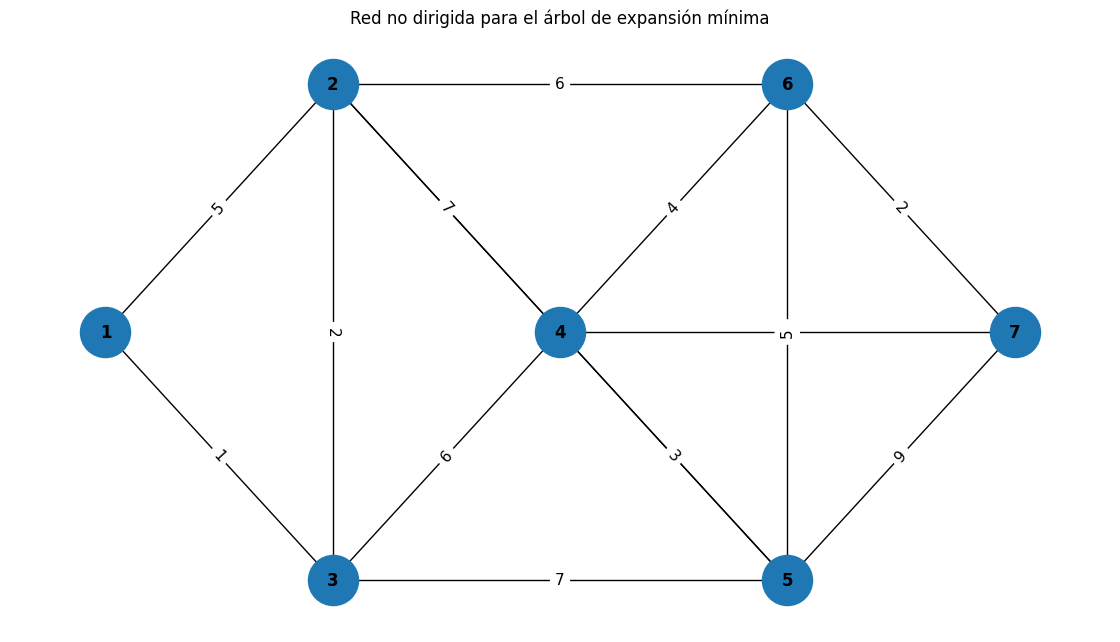

In [52]:
# Posiciones de los nodos para que la gráfica se parezca
# aproximadamente a la red proporcionada.

pos1 = {
    1: (0, 1),
        2: (1, 2),
            3: (1, 0),
                4: (2, 1),
                    5: (3, 0),
                        6: (3, 2),
                            7: (4, 1)
                            }

plt.figure(figsize=(11, 6))

nx.draw(
                                G1,
                                    pos1,
                                        with_labels=True,
                                            node_size=1300,
                                                font_size=12,
                                                    font_weight="bold"
                                                    )

                                                    # Extraemos los pesos

pesos1 = nx.get_edge_attributes(G1, "weight")

                                                    # Dibujamos los pesos sobre las aristas
nx.draw_networkx_edge_labels(
                                                        G1,
                                                            pos1,
                                                                edge_labels=pesos1,
                                                                    font_size=11
                                                                    )

plt.title("Red no dirigida para el árbol de expansión mínima")
plt.axis("off")
plt.show()

In [53]:
# ============================================================
# Cálculo del Árbol de Expansión Mínima
# ============================================================

T = nx.minimum_spanning_tree(
    G1,
        weight="weight",
            algorithm="kruskal"
            )

print("ARISTAS DEL ÁRBOL DE EXPANSIÓN MÍNIMA:\n")

for u, v, datos in T.edges(data=True):
                print(f"{u} -- {v}    peso = {datos['weight']}")

                # Peso total del árbol
                peso_total = T.size(weight="weight")

                print("\nPeso total mínimo =", peso_total)

ARISTAS DEL ÁRBOL DE EXPANSIÓN MÍNIMA:

1 -- 3    peso = 1

Peso total mínimo = 13.0
2 -- 5    peso = 1

Peso total mínimo = 13.0
2 -- 3    peso = 2

Peso total mínimo = 13.0
4 -- 5    peso = 3

Peso total mínimo = 13.0
4 -- 6    peso = 4

Peso total mínimo = 13.0
6 -- 7    peso = 2

Peso total mínimo = 13.0


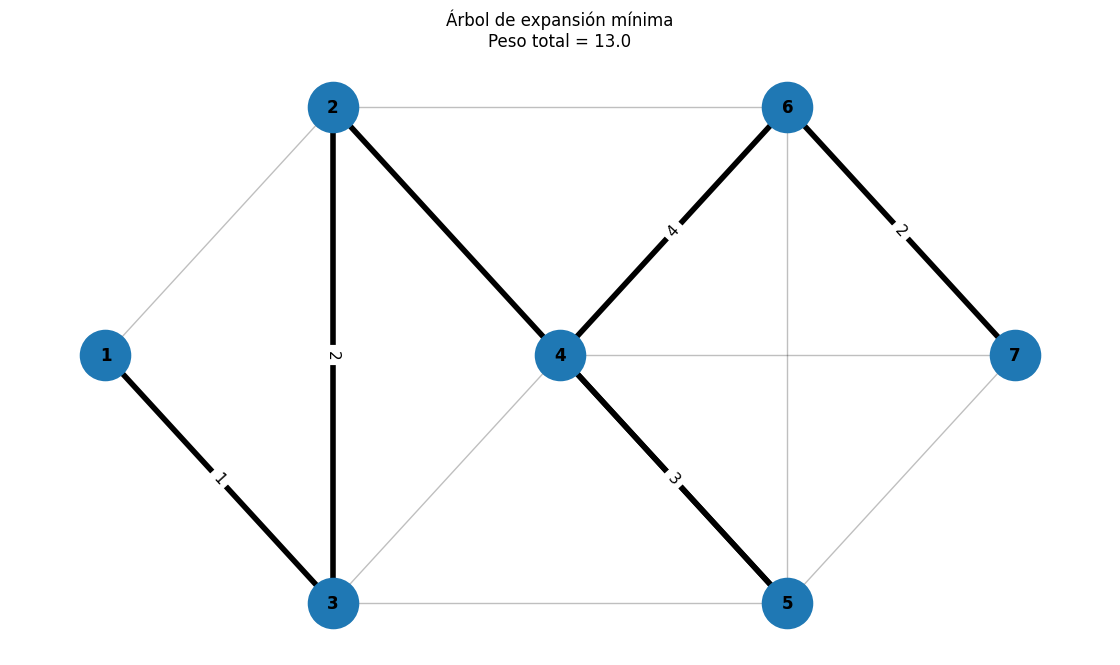

In [54]:
# Visualización del árbol de expansión mínima

plt.figure(figsize=(11, 6))

nx.draw(
    G1,
        pos1,
            with_labels=True,
                node_size=1300,
                    font_size=12,
                        font_weight="bold",
                            alpha=0.25
                            )

                            # Dibujar las aristas del árbol con mayor grosor
nx.draw_networkx_edges(
                                T,
                                    pos1,
                                        width=4
                                        )

                                        # Dibujar nuevamente los nodos
nx.draw_networkx_nodes(
                                            T,
                                                pos1,
                                                    node_size=1300
                                                    )

nx.draw_networkx_labels(
                                                        T,
                                                            pos1,
                                                                font_size=12,
                                                                    font_weight="bold"
                                                                    )

pesos_T = nx.get_edge_attributes(T, "weight")

nx.draw_networkx_edge_labels(
                                                                        T,
                                                                            pos1,
                                                                                edge_labels=pesos_T,
                                                                                    font_size=11
                                                                                    )

plt.title(
                                                                                        f"Árbol de expansión mínima\nPeso total = {peso_total}"
                                                                                        )

plt.axis("off")
plt.show()

### Resultado

El árbol obtenido conecta todos los nodos sin ciclos y con el menor peso total posible.
# 2. Ruta más corta

Se busca el camino de menor costo entre el nodo 1 y el nodo 7.

Como la red es dirigida, se utiliza `nx.DiGraph()` y el algoritmo de Dijkstra.

In [55]:
# ============================================================
# 2. RUTA MÁS CORTA
# ============================================================

G2 = nx.DiGraph()

arcos_2 = [
    (1, 2, 5),
        (1, 3, 1),

            (3, 2, 2),

                (2, 4, 7),
                    (2, 5, 1),
                        (2, 6, 6),

                            (6, 2, 7),

                                (3, 4, 6),
                                    (4, 3, 7),

                                        (3, 5, 7),

                                            (5, 4, 3),

                                                (4, 6, 4),
                                                    (4, 7, 6),

                                                        (5, 6, 5),

                                                            (6, 7, 2),
                                                                (5, 7, 9)
                                                                ]

for origen, destino, peso in arcos_2:
                                                                    G2.add_edge(origen, destino, weight=peso)

                                                                    print("Número de nodos:", G2.number_of_nodes())
                                                                    print("Número de arcos:", G2.number_of_edges())

Número de nodos: 2
Número de arcos: 1
Número de nodos: 3
Número de arcos: 2
Número de nodos: 3
Número de arcos: 3
Número de nodos: 4
Número de arcos: 4
Número de nodos: 5
Número de arcos: 5
Número de nodos: 6
Número de arcos: 6
Número de nodos: 6
Número de arcos: 7
Número de nodos: 6
Número de arcos: 8
Número de nodos: 6
Número de arcos: 9
Número de nodos: 6
Número de arcos: 10
Número de nodos: 6
Número de arcos: 11
Número de nodos: 6
Número de arcos: 12
Número de nodos: 7
Número de arcos: 13
Número de nodos: 7
Número de arcos: 14
Número de nodos: 7
Número de arcos: 15
Número de nodos: 7
Número de arcos: 16


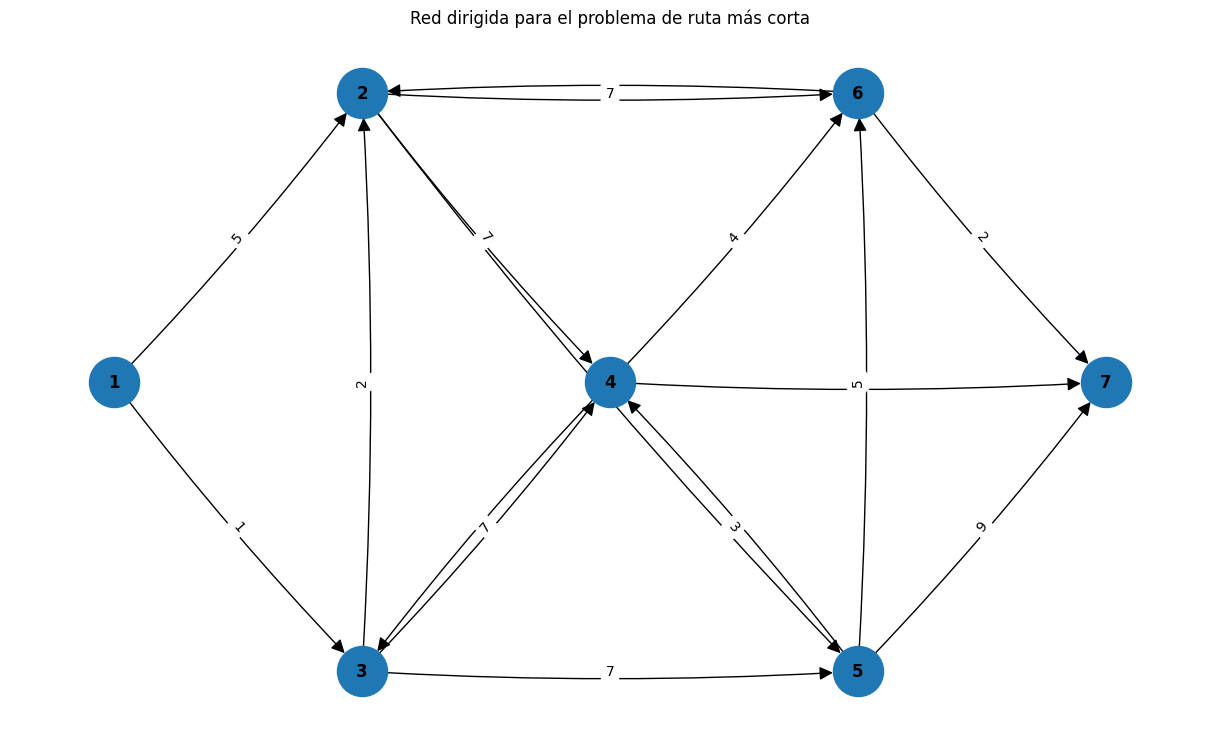

In [56]:
plt.figure(figsize=(12, 7))

nx.draw(
    G2,
        pos1,
            with_labels=True,
                node_size=1300,
                    arrows=True,
                        arrowsize=20,
                            font_size=12,
                                font_weight="bold",
                                    connectionstyle="arc3,rad=0.03"
                                    )

pesos2 = nx.get_edge_attributes(G2, "weight")

nx.draw_networkx_edge_labels(
                                        G2,
                                            pos1,
                                                edge_labels=pesos2,
                                                    font_size=10
                                                    )
plt.title("Red dirigida para el problema de ruta más corta")
plt.axis("off")
plt.show()

In [57]:
# Nodo inicial y nodo final

origen = 1
destino = 7

# Ruta más corta
ruta_corta = nx.shortest_path(
    G2,
        source=origen,
            target=destino,
                weight="weight",
                    method="dijkstra"
                    )

                    # Longitud o costo de la ruta
distancia_corta = nx.shortest_path_length(
                        G2,
                            source=origen,
                                target=destino,
                                    weight="weight",
                                        method="dijkstra"
                                        )
print("Ruta más corta:", ruta_corta)
print("Distancia mínima:", distancia_corta)

Ruta más corta: [1, 3, 2, 6, 7]
Distancia mínima: 11


In [58]:
# Convertimos la lista de nodos de la ruta en una lista de arcos

arcos_ruta = list(zip(ruta_corta, ruta_corta[1:]))

print("Arcos utilizados:")
print(arcos_ruta)

Arcos utilizados:
[(1, 3), (3, 2), (2, 6), (6, 7)]


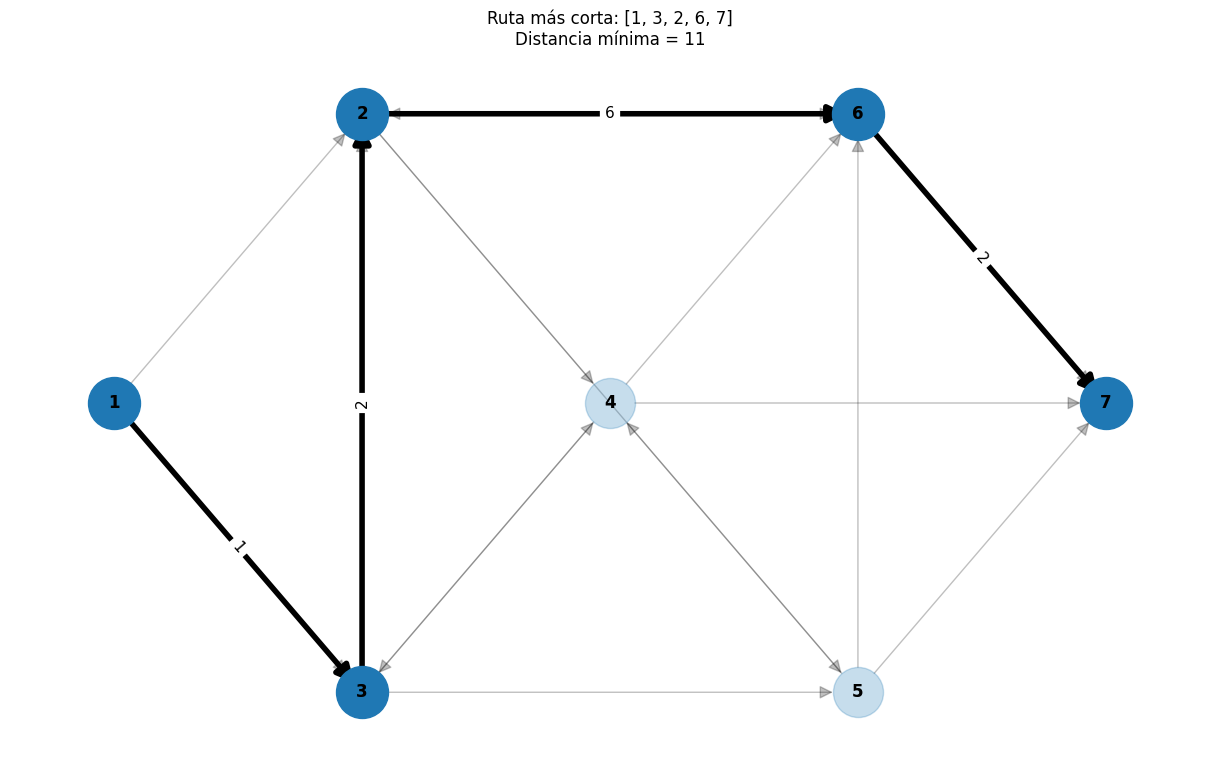

In [59]:
plt.figure(figsize=(12, 7))

# Dibujamos toda la red suavemente
nx.draw(
    G2,
        pos1,
            with_labels=True,
                node_size=1300,
                    arrows=True,
                        arrowsize=20,
                            font_size=12,
                                font_weight="bold",
                                    alpha=0.25
                                    )

                                    # Dibujamos la ruta óptima con mayor grosor
nx.draw_networkx_edges(
                                        G2,
                                            pos1,
                                                edgelist=arcos_ruta,
                                                    width=4,
                                                        arrows=True,
                                                            arrowsize=25
                                                            )

                                                            # Volvemos a dibujar los nodos de la ruta
nx.draw_networkx_nodes(
                                                                G2,
                                                                    pos1,
                                                                        nodelist=ruta_corta,
                                                                            node_size=1400
                                                                            )
nx.draw_networkx_labels(
                                                                                G2,
                                                                                    pos1,
                                                                                        font_size=12,
                                                                                            font_weight="bold"
                                                                                            )

                                                                                            # Pesos solamente de los arcos utilizados
pesos_ruta = {
                                                                                                (u, v): G2[u][v]["weight"]
                                                                                                    for u, v in arcos_ruta
                                                                                                    }

nx.draw_networkx_edge_labels(
                                                                                                        G2,
                                                                                                            pos1,
                                                                                                                edge_labels=pesos_ruta,
                                                                                                                    font_size=11
                                                                                                                    )

plt.title(
                                                                                                                        f"Ruta más corta: {ruta_corta}\n"
                                                                                                                            f"Distancia mínima = {distancia_corta}"
                                                                                                                            )

plt.axis("off")
plt.show()

### Resultado

La ruta mostrada es el camino de menor costo entre el origen y el destino.
# 3. Flujo máximo

Se busca la mayor cantidad de flujo que puede enviarse del nodo 1 al nodo 5 respetando las capacidades de los arcos.

In [60]:
# ============================================================
# 3. FLUJO MÁXIMO
# ============================================================

G3 = nx.DiGraph()

# (origen, destino, capacidad)

capacidades = [
    (1, 2, 8),
        (2, 1, 0),

            (1, 3, 14),
                (3, 1, 0),

                    (1, 5, 4),
                        (5, 1, 0),

                            (2, 3, 5),
                                (3, 2, 10),

                                    (2, 4, 7),
                                        (4, 2, 6),

                                            (2, 5, 6),
                                                (5, 2, 0),

                                                    (3, 4, 9),
                                                        (4, 3, 7),

                                                            (3, 5, 10),
                                                                (5, 3, 0),

                                                                    (4, 5, 5),
                                                                        (5, 4, 0)
                                                                        ]

for origen, destino, capacidad in capacidades:
                                                                            G3.add_edge(
                                                                                    origen,
                                                                                            destino,
                                                                                                    capacity=capacidad
                                                                                                        )

print("Número de nodos:", G3.number_of_nodes())
print("Número de arcos:", G3.number_of_edges())

Número de nodos: 5
Número de arcos: 18


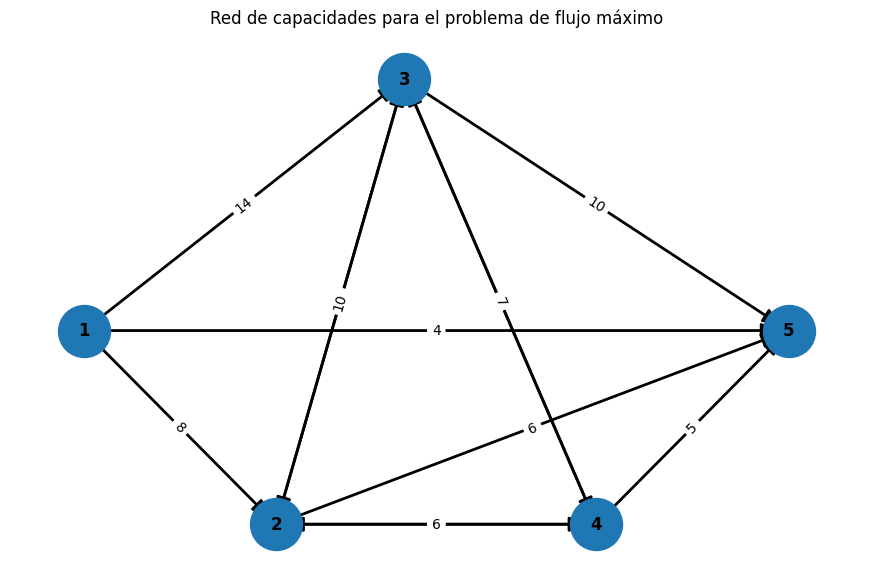

In [61]:
pos3 = {
      1: (0, 1),
          2: (1.5, 0),
              3: (2.5, 2.3),
                  4: (4, 0),
                      5: (5.5, 1)
                      }

plt.figure(figsize=(11, 7))

                      # Para evitar mostrar los arcos de capacidad 0,
                      # dibujamos únicamente aquellos con capacidad positiva.

arcos_positivos = [
                          (u, v)
                              for u, v, datos in G3.edges(data=True)
                                  if datos["capacity"] > 0
                                  ]
nx.draw_networkx_nodes(
                                      G3,
                                          pos3,
                                              node_size=1400
                                              )

nx.draw_networkx_labels(
                                                  G3,
                                                      pos3,
                                                          font_size=12,
                                                              font_weight="bold"
                                                              )

nx.draw_networkx_edges(
                                                                  G3,
                                                                      pos3,
                                                                          edgelist=arcos_positivos,
                                                                              arrows=True,
                                                                                  arrowsize=22,
                                                                                      width=2
                                                                                      )

capacidades_etiquetas = {
                                                                                          (u, v): G3[u][v]["capacity"]
                                                                                              for u, v in arcos_positivos
                                                                                              }

nx.draw_networkx_edge_labels(
                                                                                                  G3,
                                                                                                      pos3,
                                                                                                          edge_labels=capacidades_etiquetas,
                                                                                                              font_size=10
                                                                                                              )

plt.title("Red de capacidades para el problema de flujo máximo")
plt.axis("off")
plt.show(
)

In [62]:
# ============================================================
# CÁLCULO Y DISTRIBUCIÓN DEL FLUJO MÁXIMO
# ============================================================

fuente = 1
sumidero = 5

valor_flujo, flujo = nx.maximum_flow(
    G3,
        fuente,
            sumidero,
                capacity="capacity"
                )

print("FLUJO MÁXIMO =", valor_flujo)

print("\nDISTRIBUCIÓN DEL FLUJO:\n")

for u in flujo:
                    for v in flujo[u]:
                            if G3.has_edge(u, v):
                                        capacidad = G3[u][v]["capacity"]
f = flujo[u][v]

if capacidad > 0:
                                                                                print(
                                                                                                    f"{u} -> {v}: "
                                                                                                                        f"flujo = {f}, "
                                                                                                                                            f"capacidad = {capacidad}"
                                                                                                                                                            )

FLUJO MÁXIMO = 25

DISTRIBUCIÓN DEL FLUJO:

4 -> 5: flujo = 5, capacidad = 5


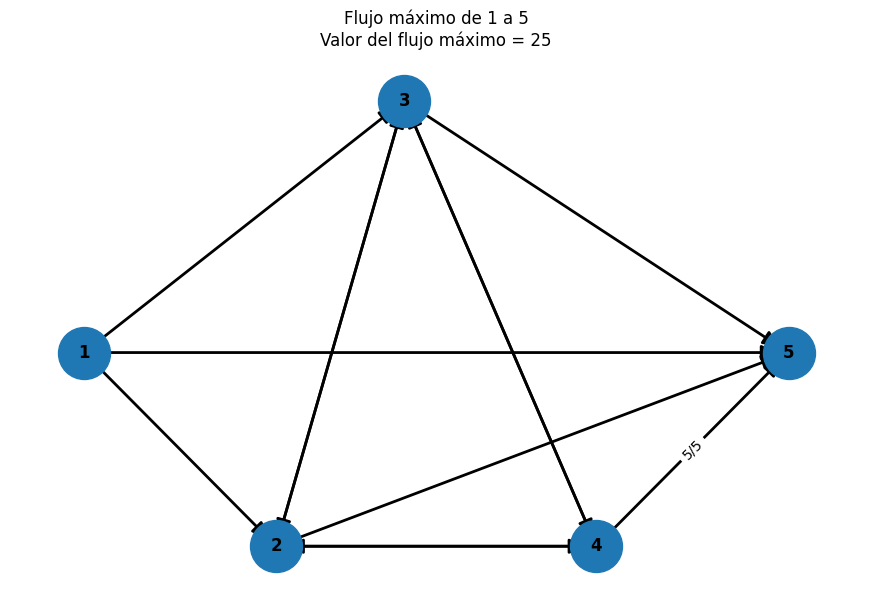

In [63]:
# ============================================================
# Visualización del flujo máximo
# ============================================================

plt.figure(figsize=(11, 7))

nx.draw_networkx_nodes(
    G3,
        pos3,
            node_size=1400
            )

nx.draw_networkx_labels(
                G3,
                    pos3,
                        font_size=12,
                            font_weight="bold"
                            )

nx.draw_networkx_edges(
                                G3,
                                    pos3,
                                        edgelist=arcos_positivos,
                                            arrows=True,
                                                arrowsize=22,
                                                    width=2
                                                    )

                                                    # Etiquetas flujo/capacidad
etiquetas_flujo = {}

for u, v in arcos_positivos:

                                                        capacidad = G3[u][v]["capacity"]
f = flujo[u][v]

etiquetas_flujo[(u, v)] = f"{f}/{capacidad}"

nx.draw_networkx_edge_labels(
                                                                    G3,
                                                                        pos3,
                                                                            edge_labels=etiquetas_flujo,
                                                                                font_size=10
                                                                                )

plt.title(
                                                                                    f"Flujo máximo de {fuente} a {sumidero}\n"
                                                                                        f"Valor del flujo máximo = {valor_flujo}"
                                                                                        )

plt.axis("off")
plt.show()

### Resultado

El flujo máximo obtenido es:

$$
\boxed{F_{\max}=25}
$$
# Conclusión

NetworkX permite resolver y visualizar problemas de redes como árbol de expansión mínima, ruta más corta y flujo máximo.